<a href="https://colab.research.google.com/github/nadineashmawey/arabic-sign-language-recognition/blob/main/01_Arabic_sign_language.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In this section, we load and inspect the Arabic Sign Language dataset
before applying preprocessing or training a machine learning model.

In [3]:
!pip install -q -U kagglehub

In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "muhammadalbrham/rgb-arabic-alphabets-sign-language-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 4.73G/4.73G [04:44<00:00, 17.9MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/muhammadalbrham/rgb-arabic-alphabets-sign-language-dataset/versions/5


In [5]:
import os

print(os.listdir(dataset_path))

['RGB ArSL dataset']


In [6]:
data_dir = os.path.join(dataset_path, "RGB ArSL dataset")

print(os.listdir(data_dir))

['Zah', 'Teh_Marbuta', 'Heh', 'Seen', 'Beh', 'Zain', 'Alef', 'Yeh', 'Tah', 'Qaf', 'Feh', 'Waw', 'Laa', 'Kaf', 'Thal', 'Hah', 'Meem', 'Sad', 'Dad', 'Sheen', 'Theh', 'Jeem', 'Teh', 'Reh', 'Dal', 'Ain', 'Al', 'Khah', 'Noon', 'Ghain', 'Lam']


In [7]:
#checking whether the dataset is imbalanced
class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)

{'Zah': 232, 'Teh_Marbuta': 257, 'Heh': 253, 'Seen': 266, 'Beh': 307, 'Zain': 201, 'Alef': 287, 'Yeh': 272, 'Tah': 226, 'Qaf': 219, 'Feh': 255, 'Waw': 249, 'Laa': 268, 'Kaf': 264, 'Thal': 202, 'Hah': 246, 'Meem': 253, 'Sad': 270, 'Dad': 266, 'Sheen': 278, 'Theh': 305, 'Jeem': 210, 'Teh': 311, 'Reh': 227, 'Dal': 235, 'Ain': 244, 'Al': 276, 'Khah': 250, 'Noon': 237, 'Ghain': 230, 'Lam': 260}


The dataset contains 31 sign classes with approximately 200–310 images per class, indicating a relatively balanced class distribution.

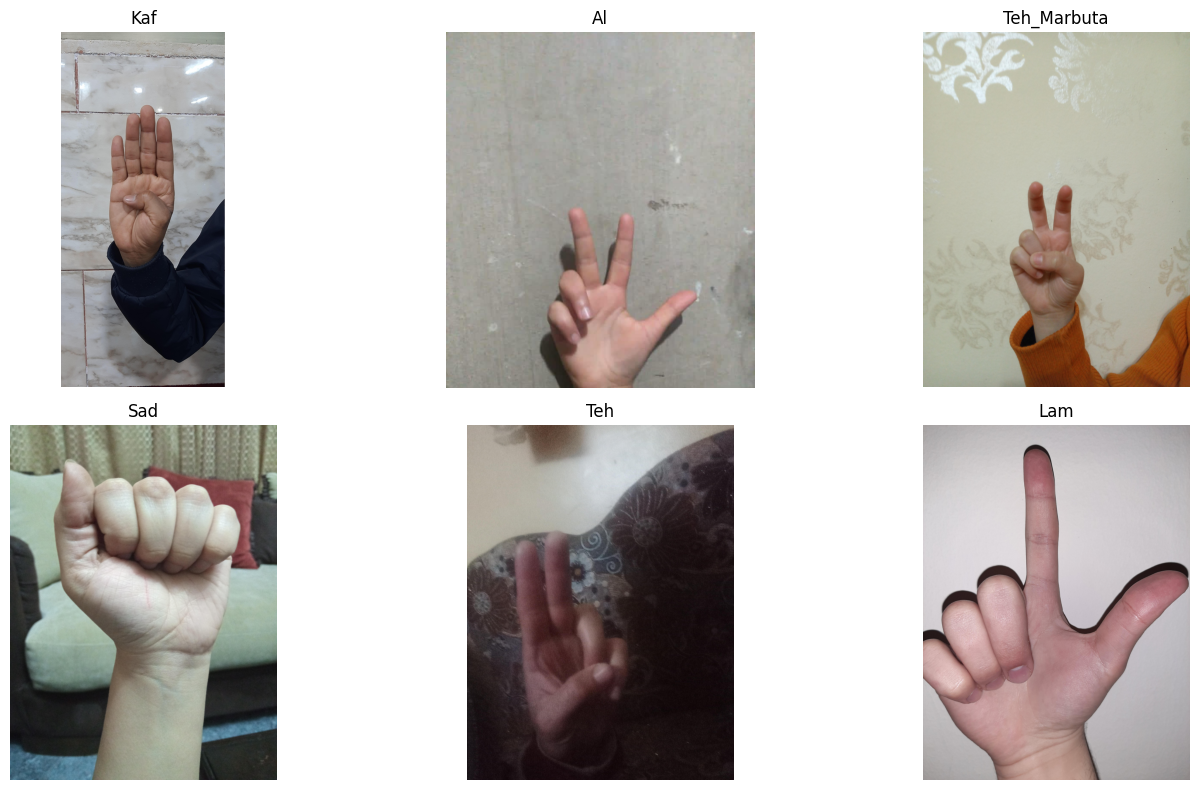

In [8]:
import random
import cv2

selected_classes = random.sample(list(class_counts.keys()), 6)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image shape: (4032, 3024, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [10]:
#checking resolution of different image samples
for i in range(10):
    class_name = random.choice(list(class_counts.keys()))
    class_path = os.path.join(data_dir, class_name)

    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = cv2.imread(image_path)

    print(class_name, "->", img.shape)

Waw -> (4096, 2304, 3)
Teh -> (6528, 4896, 3)
Qaf -> (2944, 1324, 3)
Beh -> (3088, 2320, 3)
Feh -> (2190, 1642, 3)
Thal -> (682, 508, 3)
Zah -> (4608, 3456, 3)
Kaf -> (3632, 1964, 3)
Jeem -> (3088, 2320, 3)
Al -> (3968, 2976, 3)


we will use 224 * 224 * 3 image resolution , so we need to resize all images to this size

In [11]:
#testing padding to avoid squashing the hand pictures

resized_image = tf.image.resize_with_pad(
    image,
    target_height=224,
    target_width=224
)

print("Original shape:", image.shape)
print("New shape:", resized_image.shape)

Original shape: (4032, 3024, 3)
New shape: (224, 224, 3)


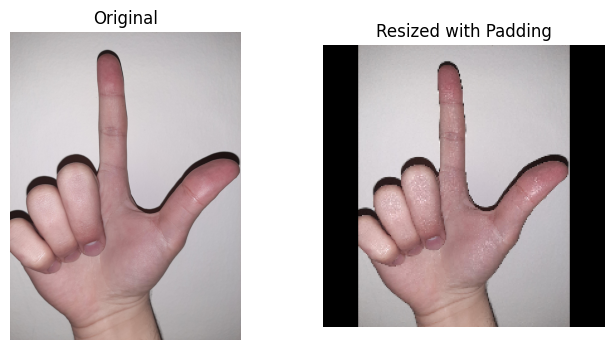

In [12]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(resized_image, tf.uint8))
plt.title("Resized with Padding")
plt.axis("off")

plt.show()

the shape of the fingers and hand is extremely important for sign classification

In [13]:
classes_to_check = ["Alef", "Beh", "Teh"]

for class_name in classes_to_check:
    class_path = os.path.join(data_dir, class_name)

    print(f"\n{class_name}:")
    print(os.listdir(class_path)[:10])


Alef:
['Alef_90.jpg', 'Alef_10.jpg', 'Alef_179.jpg', 'Alef_243.jpg', 'Alef_259.jpg', 'Alef_142.jpeg', 'Alef_173.jpg', 'Alef_4.jpg', 'Alef_2.jpg', 'Alef_268.jpg']

Beh:
['Beh_248.jpeg', 'Beh_79.jpg', 'Beh_165.jpg', 'Beh_197.jpg', 'Beh_49.jpg', 'Beh_240.jpg', 'Beh_145.jpg', 'Beh_216.jpg', 'Beh_188.jpg', 'Beh_45.jpg']

Teh:
['Teh_1.jpg', 'Teh_191.jpg', 'Teh_180.jpg', 'Teh_298.jpg', 'Teh_21.jpg', 'Teh_295.jpg', 'Teh_226.jpg', 'Teh_8.jpeg', 'Teh_256.jpg', 'Teh_82.jpg']


we will use stratified split 70% training
                     15% validation
                     15% testing , since stratification tries to preserve the class proportions

In [14]:
import pandas as pd

filepaths = []
labels = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            filepaths.append(image_path)
            labels.append(class_name)

data = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

data.head()

,filepath,label
0,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
1,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
2,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
3,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
4,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah


In [15]:
print("Total images:", len(data))
print("Number of classes:", data["label"].nunique())

data.head()

Total images: 7856
Number of classes: 31


,filepath,label
0,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
1,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
2,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
3,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah
4,/root/.cache/kagglehub/datasets/muhammadalbrha...,Zah


In [16]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42,
    stratify=data["label"]
)

In [17]:
val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=temp_data["label"]
)

In [18]:
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Testing images:", len(test_data))

Training images: 5499
Validation images: 1178
Testing images: 1179


In [19]:
#making sure splits are stratified
print("TRAIN")
print(train_data["label"].value_counts(normalize=True).head())

print("\nVALIDATION")
print(val_data["label"].value_counts(normalize=True).head())

print("\nTEST")
print(test_data["label"].value_counts(normalize=True).head())

TRAIN
label
Teh      0.039644
Beh      0.039098
Theh     0.038734
Alef     0.036552
Sheen    0.035461
Name: proportion, dtype: float64

VALIDATION
label
Theh    0.039049
Beh     0.039049
Teh     0.039049
Alef    0.036503
Al      0.034805
Name: proportion, dtype: float64

TEST
label
Teh     0.039864
Theh    0.039016
Beh     0.039016
Alef    0.036472
Al      0.035623
Name: proportion, dtype: float64


In [20]:
class_names = sorted(data["label"].unique())

print(class_names)
print("Number of classes:", len(class_names))

['Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain']
Number of classes: 31


In [21]:
#label encoding
label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

print(label_to_index)

{'Ain': 0, 'Al': 1, 'Alef': 2, 'Beh': 3, 'Dad': 4, 'Dal': 5, 'Feh': 6, 'Ghain': 7, 'Hah': 8, 'Heh': 9, 'Jeem': 10, 'Kaf': 11, 'Khah': 12, 'Laa': 13, 'Lam': 14, 'Meem': 15, 'Noon': 16, 'Qaf': 17, 'Reh': 18, 'Sad': 19, 'Seen': 20, 'Sheen': 21, 'Tah': 22, 'Teh': 23, 'Teh_Marbuta': 24, 'Thal': 25, 'Theh': 26, 'Waw': 27, 'Yeh': 28, 'Zah': 29, 'Zain': 30}


In [22]:
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

train_data["label_id"] = train_data["label"].map(label_to_index)
val_data["label_id"] = val_data["label"].map(label_to_index)
test_data["label_id"] = test_data["label"].map(label_to_index)

In [23]:
#processing one image
IMG_SIZE = 224

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [24]:
def create_dataset(dataframe, shuffle=False):

    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(32)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [25]:
train_ds = create_dataset(train_data, shuffle=True)

val_ds = create_dataset(val_data)

test_ds = create_dataset(test_data)

In [26]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

    print("\nFirst 10 labels:")
    print(labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)

First 10 labels:
[24  2 17 22  3 21  9 28 27 10]


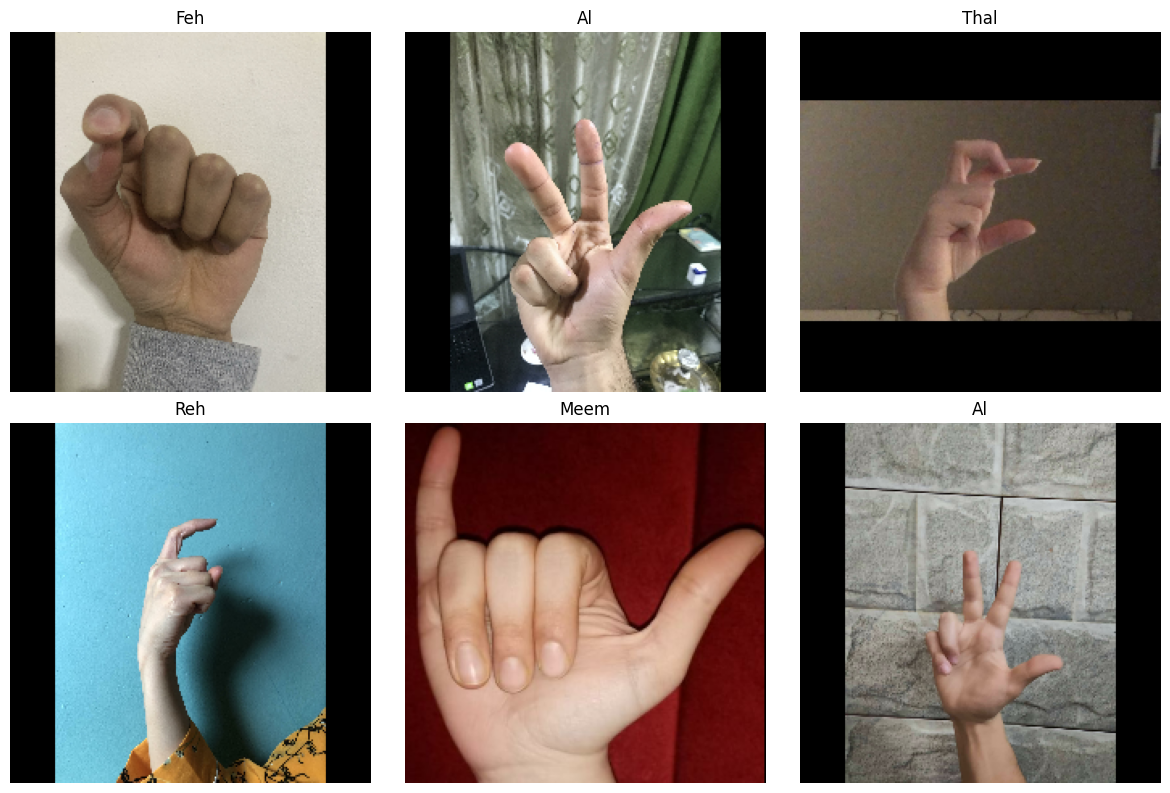

In [27]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(6):

        plt.subplot(2, 3, i + 1)

        plt.imshow(
            tf.cast(images[i], tf.uint8)
        )

        label_number = labels[i].numpy()

        plt.title(
            class_names[label_number]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

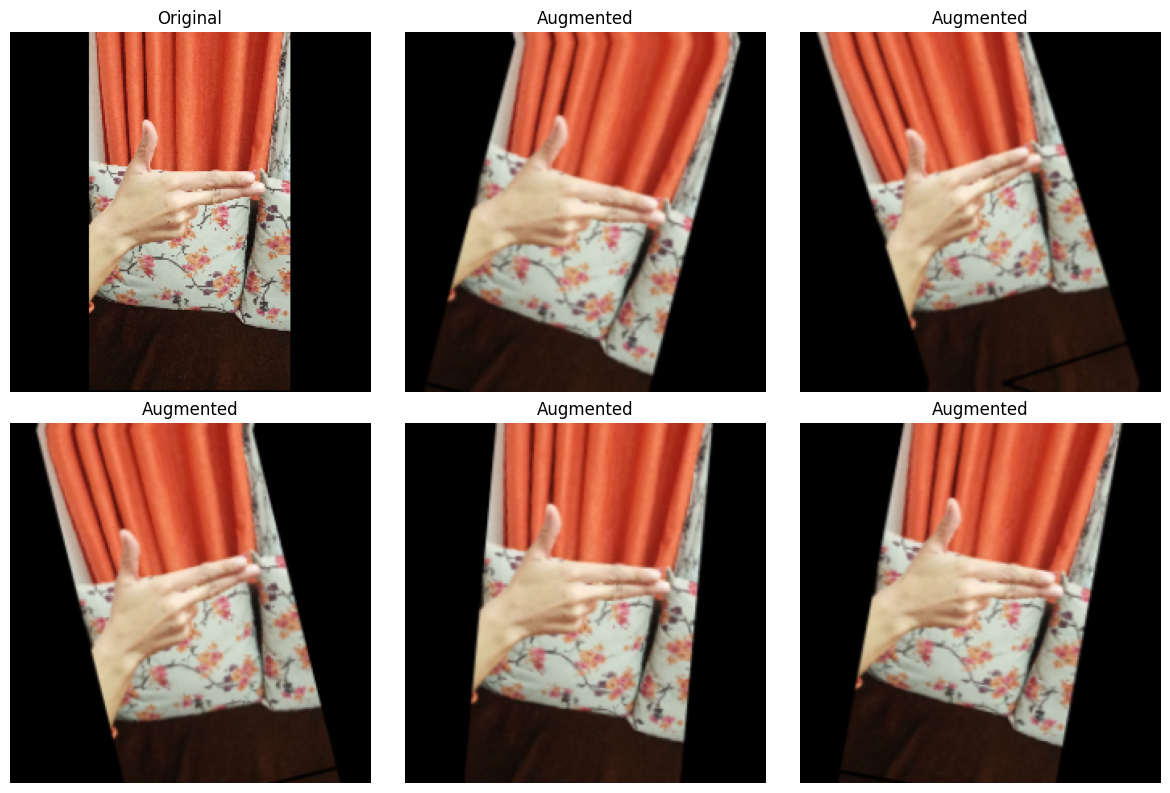

In [29]:
for images, labels in train_ds.take(1):

    original = images[0]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(tf.cast(original, tf.uint8))
    plt.title("Original")
    plt.axis("off")

    for i in range(5):
        augmented = data_augmentation(
            tf.expand_dims(original, 0),
            training=True
        )

        plt.subplot(2, 3, i + 2)
        plt.imshow(
            tf.cast(augmented[0], tf.uint8)
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [31]:
base_model.trainable = False

In [32]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

In [33]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │        39,711 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,297,695 (8.77 MB)

 Trainable params: 39,711 (155.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [36]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.1982 - loss: 2.9178 - val_accuracy: 0.3523 - val_loss: 2.1617
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.4001 - loss: 2.0209 - val_accuracy: 0.4550 - val_loss: 1.8199
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.4825 - loss: 1.7026 - val_accuracy: 0.4652 - val_loss: 1.7216
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.5346 - loss: 1.5363 - val_accuracy: 0.4822 - val_loss: 1.5705
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.5679 - loss: 1.4087 - val_accuracy: 0.5229 - val_loss: 1.5313


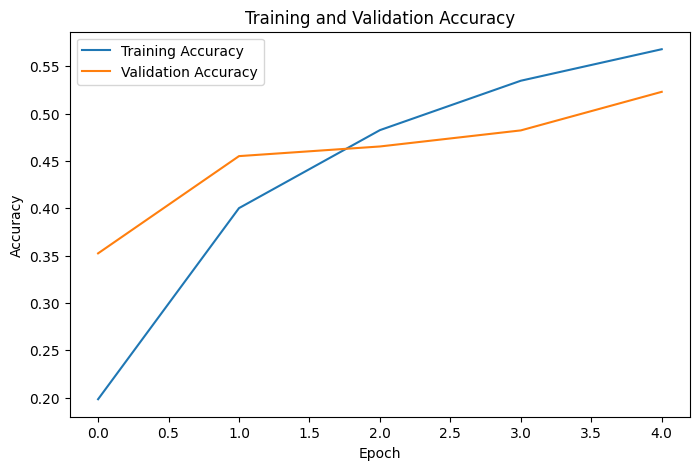

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

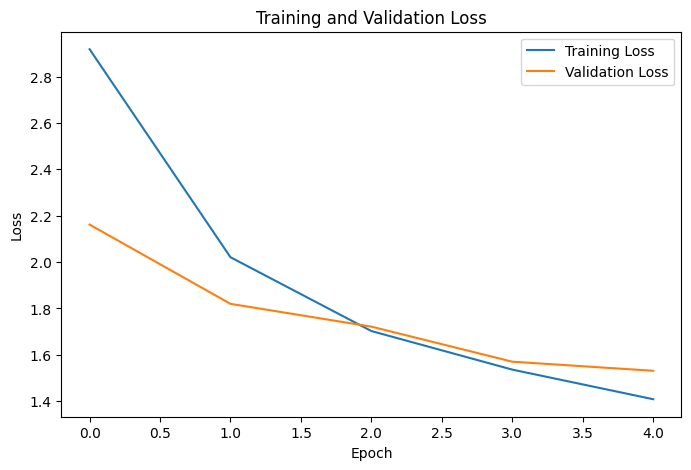

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [39]:
model.save("arabic_sign_before_finetuning.keras")

In [40]:
base_model.trainable = True

In [41]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [42]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_finetuned_arabic_sign_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [44]:
fine_tune_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [45]:
fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [46]:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr
    ]
)

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.4108 - loss: 1.9741
Epoch 1: val_accuracy improved from None to 0.54499, saving model to best_finetuned_arabic_sign_model.keras

Epoch 1: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.4610 - loss: 1.7872 - val_accuracy: 0.5450 - val_loss: 1.4776 - learning_rate: 1.0000e-05
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.5618 - loss: 1.3852
Epoch 2: val_accuracy improved from 0.54499 to 0.57131, saving model to best_finetuned_arabic_sign_model.keras

Epoch 2: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.5852 - loss: 1.3336 - val_accuracy: 0.5713 - val_loss: 1.3290 - learning_rate: 1.0000e-05
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.6338 - loss: 1.1614
Epoch 3: val_accuracy improved from 0.57131 to 0.61121, saving model to best_

In [47]:
history_ft2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=15,
    epochs=20,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stop,
        fine_tune_reduce_lr
    ]
)

Epoch 16/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.8674 - loss: 0.4265
Epoch 16: val_accuracy improved from 0.78438 to 0.78523, saving model to best_finetuned_arabic_sign_model.keras

Epoch 16: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.8669 - loss: 0.4183 - val_accuracy: 0.7852 - val_loss: 0.6278 - learning_rate: 1.0000e-05
Epoch 17/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.8840 - loss: 0.4110
Epoch 17: val_accuracy improved from 0.78523 to 0.79287, saving model to best_finetuned_arabic_sign_model.keras

Epoch 17: finished saving model to best_finetuned_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8796 - loss: 0.4021 - val_accuracy: 0.7929 - val_loss: 0.6160 - learning_rate: 1.0000e-05
Epoch 18/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.8760 - loss: 0.3853
Epoch 18: val_accuracy improved from 0.79287 to 0.79711, saving mod

In [48]:
model.save("arabic_sign_stage1_80percent.keras")

In [49]:
base_model.trainable = True

# Freeze everything except the last 60 layers
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [50]:
trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Number of trainable MobileNetV2 layers:",
      len(trainable_layers))

print("\nLast trainable layers:")
print(trainable_layers[-10:])

Number of trainable MobileNetV2 layers: 19

Last trainable layers:
['block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1', 'out_relu']


In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
stage2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_stage2_arabic_sign_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

stage2_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

stage2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [53]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=20,
    epochs=30,
    callbacks=[
        stage2_checkpoint,
        stage2_early_stop,
        stage2_reduce_lr
    ]
)

Epoch 21/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.9177 - loss: 0.2724
Epoch 21: val_accuracy improved from None to 0.80306, saving model to best_stage2_arabic_sign_model.keras

Epoch 21: finished saving model to best_stage2_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9167 - loss: 0.2727 - val_accuracy: 0.8031 - val_loss: 0.5754 - learning_rate: 5.0000e-06
Epoch 22/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.9167 - loss: 0.2477
Epoch 22: val_accuracy improved from 0.80306 to 0.80730, saving model to best_stage2_arabic_sign_model.keras

Epoch 22: finished saving model to best_stage2_arabic_sign_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9149 - loss: 0.2564 - val_accuracy: 0.8073 - val_loss: 0.5689 - learning_rate: 5.0000e-06
Epoch 23/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.9300 - loss: 0.2355
Epoch 23: val_accuracy did not improve from 0.80730
172/172 ━━━━━━━━━━━━━━━━━━━━ 2

KeyboardInterrupt: 

In [54]:
best_model = tf.keras.models.load_model(
    "best_stage2_arabic_sign_model.keras"
)

In [55]:
import numpy as np

y_val_true = np.concatenate([
    labels.numpy()
    for images, labels in val_ds
])

In [56]:
y_val_prob = best_model.predict(val_ds)

y_val_pred = np.argmax(
    y_val_prob,
    axis=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 836ms/step


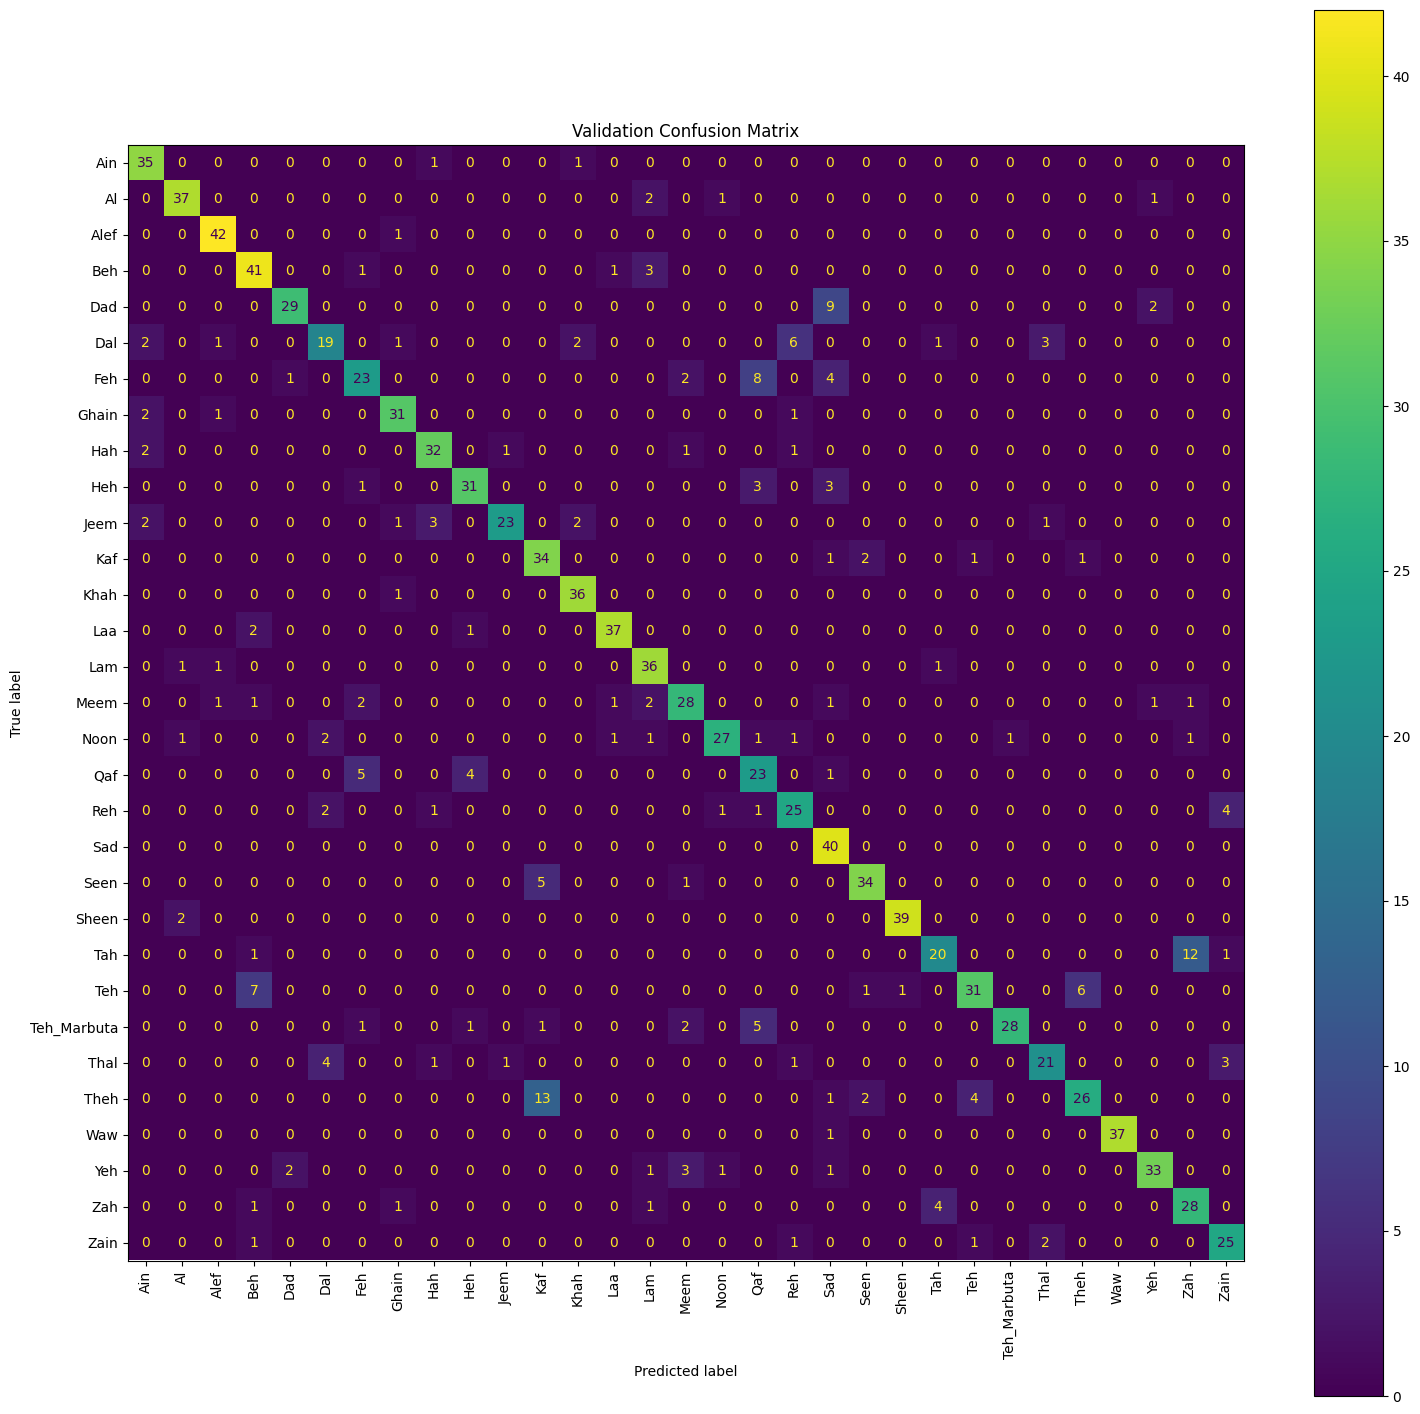

In [57]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_true,
    y_val_pred
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Validation Confusion Matrix")
plt.show()

In [58]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_results = pd.DataFrame({
    "Class": class_names,
    "Accuracy": per_class_accuracy
})

class_results["Accuracy_Percent"] = (
    class_results["Accuracy"] * 100
)

class_results = class_results.sort_values(
    "Accuracy"
)

print(class_results[
    ["Class", "Accuracy_Percent"]
].to_string(index=False))

      Class  Accuracy_Percent
        Dal         54.285714
       Theh         56.521739
        Tah         58.823529
        Feh         60.526316
        Teh         67.391304
       Thal         67.741935
        Qaf         69.696970
       Jeem         71.875000
        Dad         72.500000
        Reh         73.529412
       Meem         73.684211
Teh_Marbuta         73.684211
       Noon         75.000000
        Zah         80.000000
        Yeh         80.487805
        Heh         81.578947
       Zain         83.333333
       Seen         85.000000
        Hah         86.486486
        Kaf         87.179487
      Ghain         88.571429
        Beh         89.130435
         Al         90.243902
        Lam         92.307692
        Laa         92.500000
        Ain         94.594595
      Sheen         95.121951
       Khah         97.297297
        Waw         97.368421
       Alef         97.674419
        Sad        100.000000


In [59]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

confusions = []

for actual_id in range(len(class_names)):
    for predicted_id in range(len(class_names)):
        count = cm_errors[actual_id, predicted_id]

        if count > 0:
            confusions.append({
                "Actual": class_names[actual_id],
                "Predicted": class_names[predicted_id],
                "Count": count
            })

confusions_df = pd.DataFrame(confusions)

confusions_df = confusions_df.sort_values(
    "Count",
    ascending=False
)

print(confusions_df.head(20).to_string(index=False))

     Actual Predicted  Count
       Theh       Kaf     13
        Tah       Zah     12
        Dad       Sad      9
        Feh       Qaf      8
        Teh       Beh      7
        Teh      Theh      6
        Dal       Reh      6
        Qaf       Feh      5
Teh_Marbuta       Qaf      5
       Seen       Kaf      5
        Qaf       Heh      4
        Feh       Sad      4
        Reh      Zain      4
       Thal       Dal      4
       Theh       Teh      4
        Zah       Tah      4
       Thal      Zain      3
        Dal      Thal      3
        Heh       Qaf      3
        Yeh      Meem      3


In [70]:
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 2.5 MB/s eta 0:00:00


In [71]:
from huggingface_hub import hf_hub_download
import importlib.util
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Download OpenCV palm detector model
palm_model_path = hf_hub_download(
    repo_id="opencv/palm_detection_mediapipe",
    filename="palm_detection_mediapipe_2023feb.onnx"
)

# Download OpenCV's Python wrapper
palm_code_path = hf_hub_download(
    repo_id="opencv/palm_detection_mediapipe",
    filename="mp_palmdet.py"
)

print("Downloaded!")

palm_detection_mediapipe_2023feb.onnx: reconstructing file:   0%|          |  0.00B / 3.91MB            

palm_detection_mediapipe_2023feb.onnx: downloading bytes:           |  0.00B            

mp_palmdet.py:   0%|          | 0.00/93.6k [00:00<?, ?B/s]

Downloaded!


In [72]:
spec = importlib.util.spec_from_file_location(
    "mp_palmdet",
    palm_code_path
)

mp_palmdet = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mp_palmdet)

MPPalmDet = mp_palmdet.MPPalmDet

In [73]:
palm_detector = MPPalmDet(
    modelPath=palm_model_path,
    nmsThreshold=0.3,
    scoreThreshold=0.5,
    topK=1,
    backendId=cv2.dnn.DNN_BACKEND_OPENCV,
    targetId=cv2.dnn.DNN_TARGET_CPU
)

print("Palm detector ready!")

Palm detector ready!


In [76]:
def crop_hand(image_path, scale=3.0):

    image = cv2.imread(image_path)

    if image is None:
        return None

    h, w, _ = image.shape

    palms = palm_detector.infer(image)

    # If no palm detected, use original image
    if palms is None or len(palms) == 0:
        return image

    # Pick detection with highest confidence
    palm = max(
        palms,
        key=lambda detection: detection[-1]
    )

    x1, y1, x2, y2 = palm[:4]

    # Palm centre
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    palm_width = x2 - x1
    palm_height = y2 - y1

    # Make a larger square so fingers are included
    size = max(palm_width, palm_height) * scale

    new_x1 = int(center_x - size / 2)
    new_x2 = int(center_x + size / 2)

    new_y1 = int(center_y - size / 2)
    new_y2 = int(center_y + size / 2)

    # Keep crop inside image
    new_x1 = max(0, new_x1)
    new_y1 = max(0, new_y1)

    new_x2 = min(w, new_x2)
    new_y2 = min(h, new_y2)

    cropped = image[
        new_y1:new_y2,
        new_x1:new_x2
    ]

    return cropped

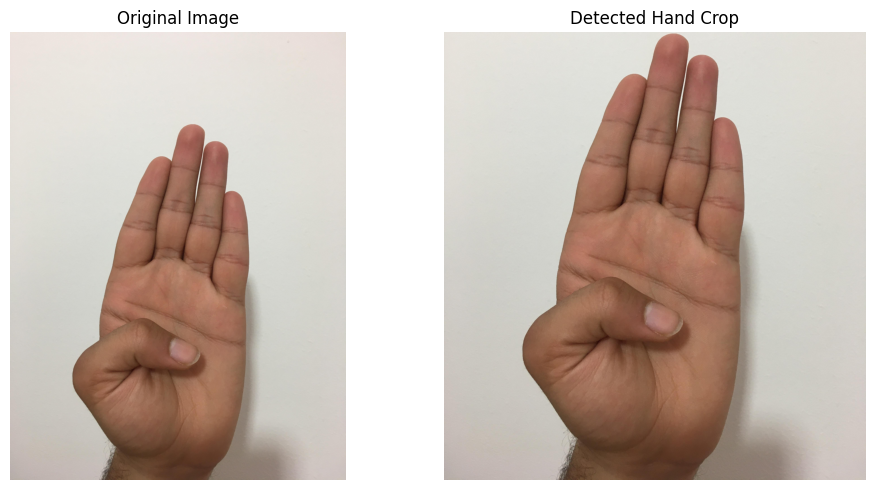

In [77]:
sample_path = train_data.iloc[0]["filepath"]

original = cv2.imread(sample_path)
cropped = crop_hand(sample_path)

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

cropped_rgb = cv2.cvtColor(
    cropped,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_rgb)
plt.title("Detected Hand Crop")
plt.axis("off")

plt.tight_layout()
plt.show()

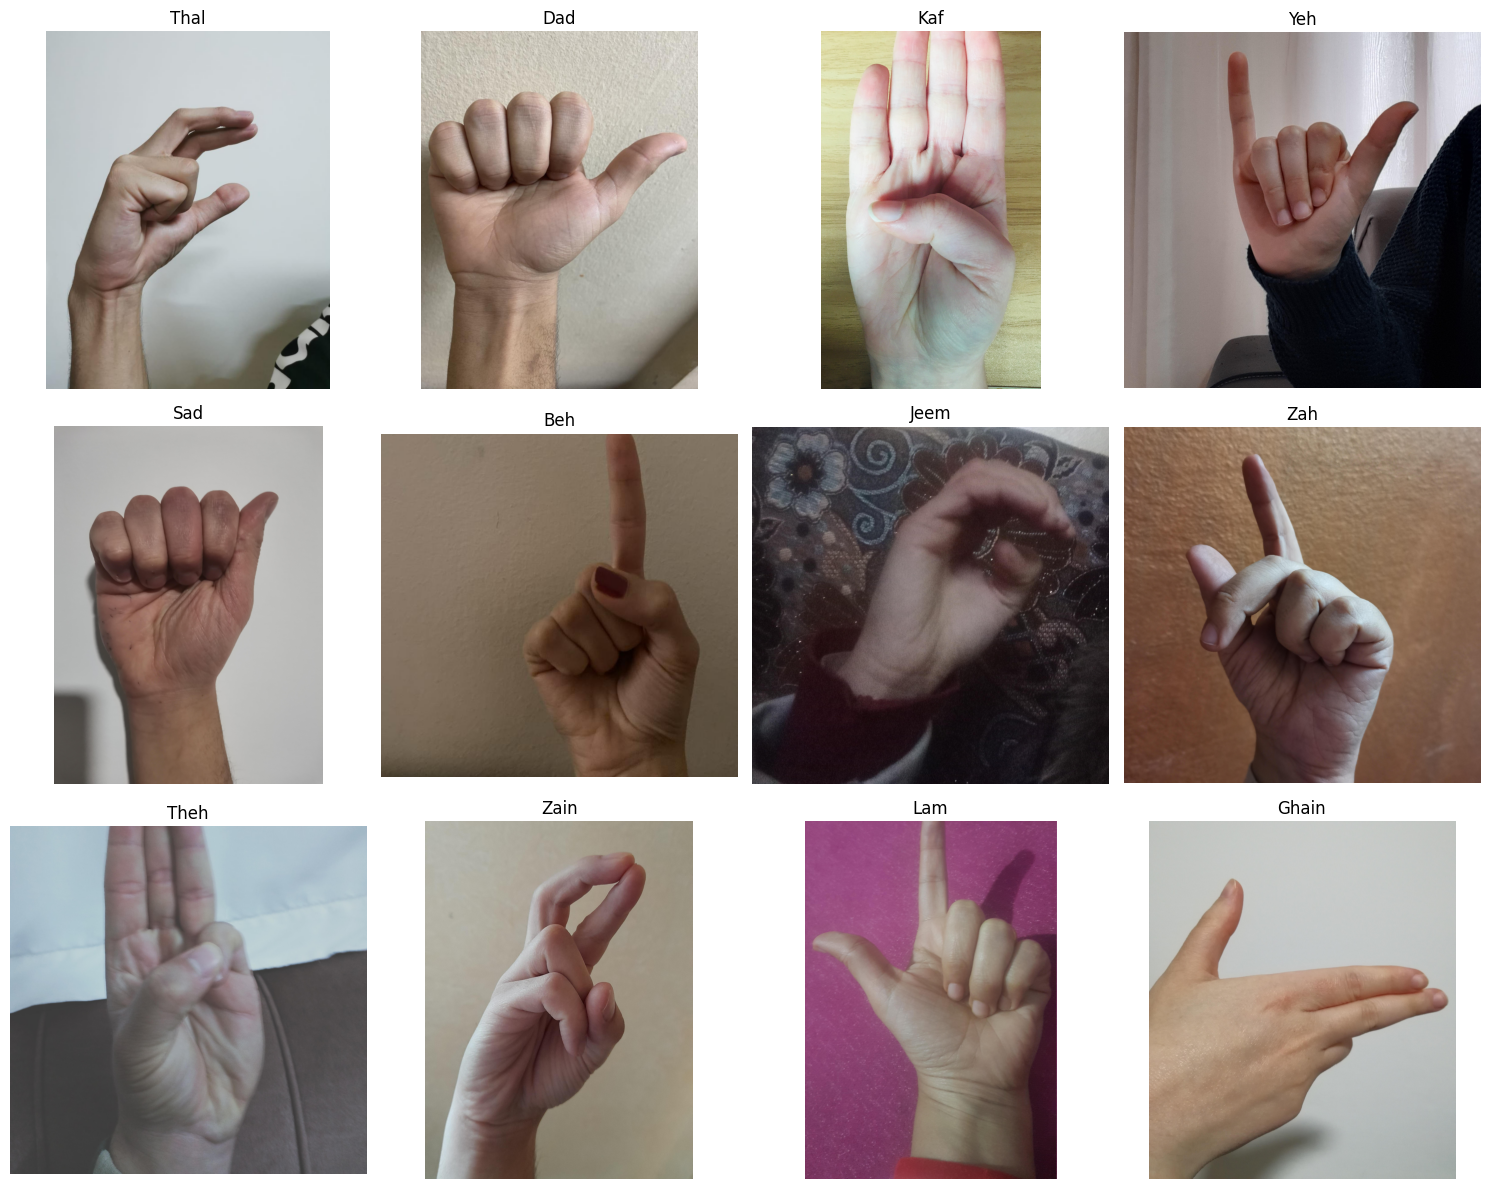

In [78]:
samples = train_data.sample(12, random_state=42)

plt.figure(figsize=(15, 12))

for i, (_, row) in enumerate(samples.iterrows()):

    cropped = crop_hand(row["filepath"])

    cropped_rgb = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3, 4, i + 1)
    plt.imshow(cropped_rgb)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [79]:
def crop_hand_with_status(image_path, scale=3.0):

    image = cv2.imread(image_path)

    if image is None:
        return None, False

    h, w, _ = image.shape

    palms = palm_detector.infer(image)

    # No hand detected
    if palms is None or len(palms) == 0:
        return image, False

    palm = max(
        palms,
        key=lambda detection: detection[-1]
    )

    x1, y1, x2, y2 = palm[:4]

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    palm_width = x2 - x1
    palm_height = y2 - y1

    size = max(
        palm_width,
        palm_height
    ) * scale

    new_x1 = int(center_x - size / 2)
    new_x2 = int(center_x + size / 2)

    new_y1 = int(center_y - size / 2)
    new_y2 = int(center_y + size / 2)

    new_x1 = max(0, new_x1)
    new_y1 = max(0, new_y1)

    new_x2 = min(w, new_x2)
    new_y2 = min(h, new_y2)

    cropped = image[
        new_y1:new_y2,
        new_x1:new_x2
    ]

    return cropped, True

In [80]:
from tqdm.auto import tqdm
import os

CROPPED_DIR = "/content/cropped_arsl"

os.makedirs(CROPPED_DIR, exist_ok=True)

In [81]:
def create_cropped_split(dataframe, split_name):

    new_data = dataframe.copy()

    cropped_paths = []
    detection_results = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe),
        desc=split_name
    ):

        label = row["label"]
        original_path = row["filepath"]

        output_folder = os.path.join(
            CROPPED_DIR,
            split_name,
            label
        )

        os.makedirs(
            output_folder,
            exist_ok=True
        )

        filename = os.path.basename(
            original_path
        )

        output_path = os.path.join(
            output_folder,
            filename
        )

        cropped, detected = crop_hand_with_status(
            original_path
        )

        if cropped is not None:

            cv2.imwrite(
                output_path,
                cropped,
                [cv2.IMWRITE_JPEG_QUALITY, 95]
            )

            cropped_paths.append(
                output_path
            )

            detection_results.append(
                detected
            )

    new_data["filepath"] = cropped_paths
    new_data["hand_detected"] = detection_results

    return new_data

In [83]:
print("crop_hand_with_status exists:",
      "crop_hand_with_status" in globals())

print("create_cropped_split exists:",
      "create_cropped_split" in globals())

crop_hand_with_status exists: True
create_cropped_split exists: True


In [84]:
cropped_train_data = create_cropped_split(
    train_data,
    "train"
)

train:   0%|          | 0/5499 [00:00<?, ?it/s]

In [85]:
cropped_val_data = create_cropped_split(
    val_data,
    "validation"
)

validation:   0%|          | 0/1178 [00:00<?, ?it/s]

In [86]:
cropped_test_data = create_cropped_split(
    test_data,
    "test"
)

test:   0%|          | 0/1179 [00:00<?, ?it/s]

In [87]:
print(
    "Train detection rate:",
    cropped_train_data["hand_detected"].mean() * 100
)

print(
    "Validation detection rate:",
    cropped_val_data["hand_detected"].mean() * 100
)

print(
    "Test detection rate:",
    cropped_test_data["hand_detected"].mean() * 100
)

Train detection rate: 89.99818148754319
Validation detection rate: 89.72835314091681
Test detection rate: 90.4156064461408


In [88]:
failure_by_class = (
    cropped_train_data
    .groupby("label")["hand_detected"]
    .agg(["mean", "count"])
)

failure_by_class["Detection_Percent"] = (
    failure_by_class["mean"] * 100
)

failure_by_class = failure_by_class.sort_values(
    "Detection_Percent"
)

print(
    failure_by_class[
        ["Detection_Percent", "count"]
    ].to_string()
)

             Detection_Percent  count
label                                
Khah                 69.714286    175
Hah                  74.418605    172
Waw                  75.862069    174
Heh                  78.531073    177
Jeem                 83.673469    147
Alef                 88.059701    201
Theh                 88.262911    213
Teh                  88.532110    218
Zain                 88.652482    141
Reh                  89.308176    159
Qaf                  89.542484    153
Teh_Marbuta          90.555556    180
Ain                  90.643275    171
Feh                  91.061453    179
Ghain                91.304348    161
Laa                  91.489362    188
Dal                  91.515152    165
Sad                  92.063492    189
Beh                  92.093023    215
Dad                  92.473118    186
Kaf                  93.513514    185
Thal                 93.617021    141
Zah                  93.827160    162
Noon                 93.975904    166
Tah         

In [89]:
palm_detector_loose = MPPalmDet(
    modelPath=palm_model_path,
    nmsThreshold=0.3,
    scoreThreshold=0.30,
    topK=1,
    backendId=cv2.dnn.DNN_BACKEND_OPENCV,
    targetId=cv2.dnn.DNN_TARGET_CPU
)

In [90]:
problem_classes = [
    "Khah",
    "Hah",
    "Waw",
    "Heh",
    "Jeem"
]

def check_detection_rate(dataframe, detector, classes):

    results = []

    for class_name in classes:

        subset = dataframe[
            dataframe["label"] == class_name
        ]

        detected_count = 0

        for path in subset["filepath"]:

            image = cv2.imread(path)

            if image is None:
                continue

            palms = detector.infer(image)

            if palms is not None and len(palms) > 0:
                detected_count += 1

        rate = (
            detected_count /
            len(subset)
        ) * 100

        results.append(
            [class_name, rate]
        )

    return pd.DataFrame(
        results,
        columns=[
            "Class",
            "Detection_Percent"
        ]
    )

In [91]:
loose_results = check_detection_rate(
    train_data,
    palm_detector_loose,
    problem_classes
)

print(loose_results)

  Class  Detection_Percent
0  Khah          84.000000
1   Hah          84.883721
2   Waw          81.034483
3   Heh          88.135593
4  Jeem          91.156463


In [92]:
palm_detector = palm_detector_loose

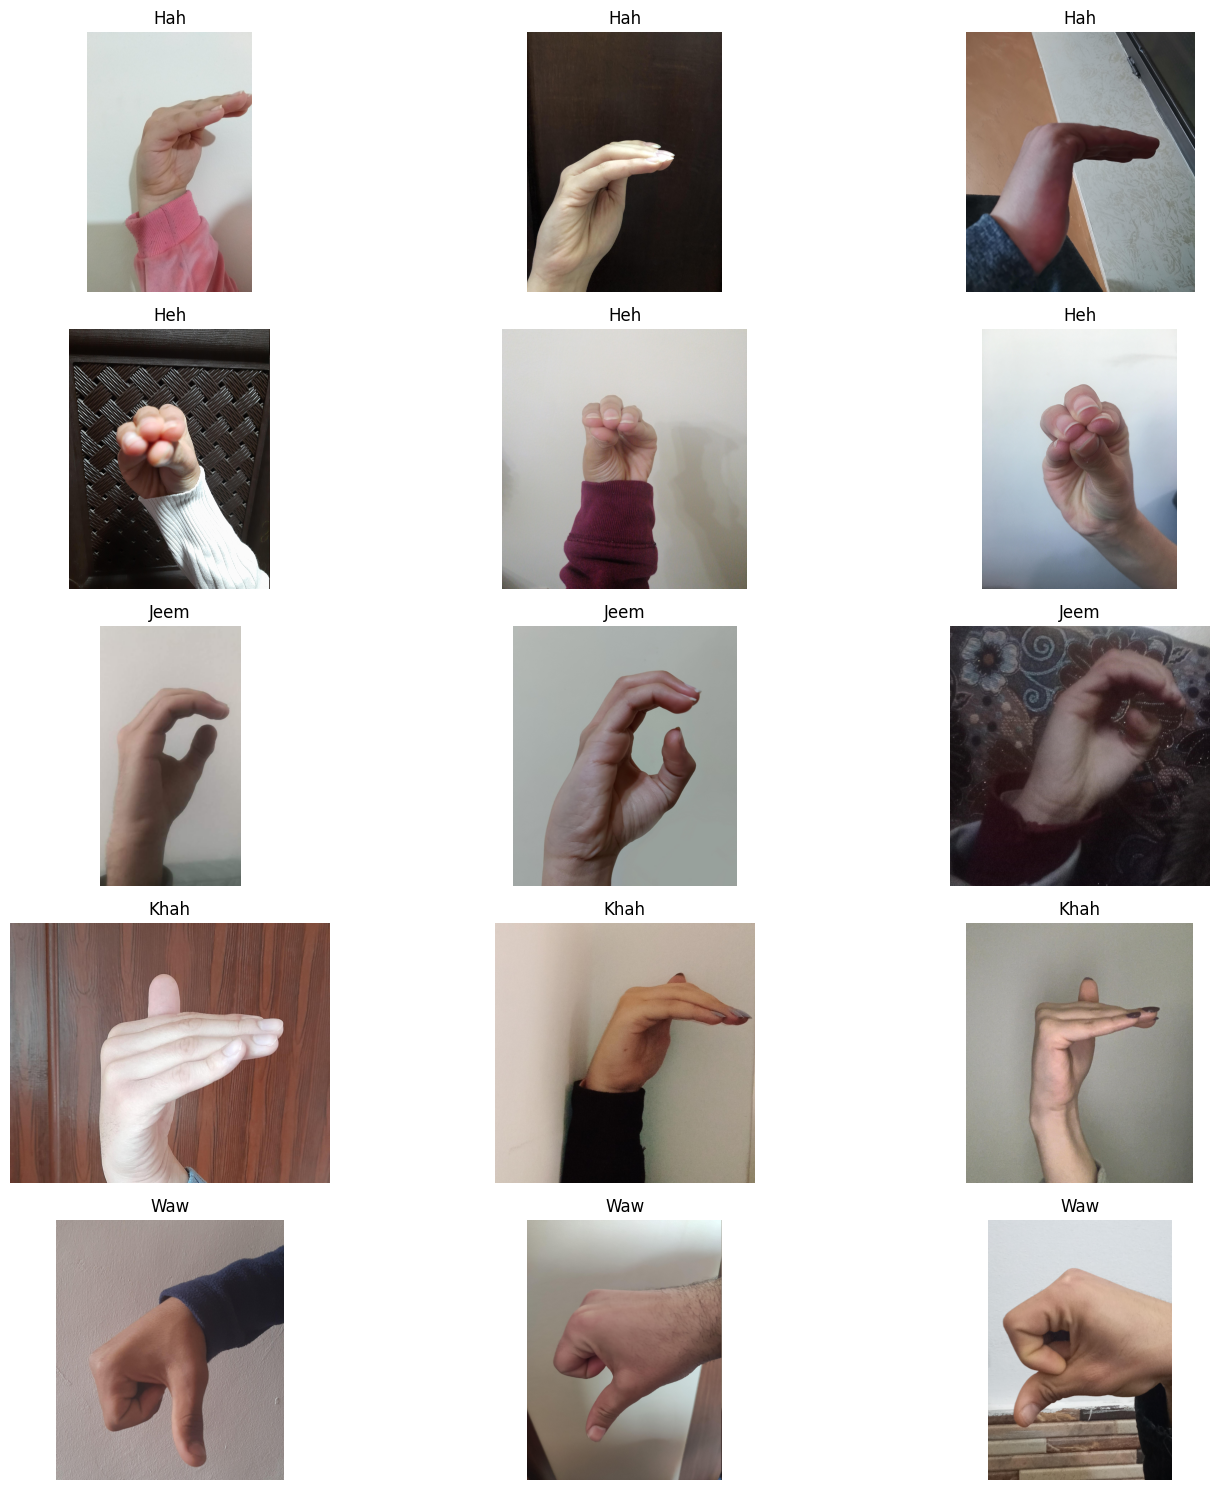

In [93]:
weak_samples = (
    train_data[
        train_data["label"].isin(problem_classes)
    ]
    .groupby("label", group_keys=False)
    .sample(n=3, random_state=42)
)

plt.figure(figsize=(15, 15))

for i, (_, row) in enumerate(
    weak_samples.iterrows()
):

    cropped = crop_hand(
        row["filepath"],
        scale=3.0
    )

    cropped_rgb = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(5, 3, i + 1)

    plt.imshow(cropped_rgb)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [94]:
import shutil
import os

# Remove crops created using the old detector
if os.path.exists(CROPPED_DIR):
    shutil.rmtree(CROPPED_DIR)

os.makedirs(CROPPED_DIR, exist_ok=True)

In [95]:
cropped_train_data = create_cropped_split(
    train_data,
    "train"
)

cropped_val_data = create_cropped_split(
    val_data,
    "validation"
)

cropped_test_data = create_cropped_split(
    test_data,
    "test"
)

train:   0%|          | 0/5499 [00:00<?, ?it/s]

validation:   0%|          | 0/1178 [00:00<?, ?it/s]

test:   0%|          | 0/1179 [00:00<?, ?it/s]

In [96]:
print(
    "Train detection rate:",
    cropped_train_data["hand_detected"].mean() * 100
)

print(
    "Validation detection rate:",
    cropped_val_data["hand_detected"].mean() * 100
)

print(
    "Test detection rate:",
    cropped_test_data["hand_detected"].mean() * 100
)

print("\nCounts:")
print("Train:", len(cropped_train_data))
print("Validation:", len(cropped_val_data))
print("Test:", len(cropped_test_data))

Train detection rate: 93.99890889252592
Validation detection rate: 93.63327674023769
Test detection rate: 94.31721798134012

Counts:
Train: 5499
Validation: 1178
Test: 1179


In [97]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_cropped_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
        image,
        IMG_SIZE,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [98]:
def create_cropped_dataset(
    dataframe,
    shuffle=False
):

    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_cropped_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [99]:
cropped_train_ds = create_cropped_dataset(
    cropped_train_data,
    shuffle=True
)

cropped_val_ds = create_cropped_dataset(
    cropped_val_data
)

cropped_test_ds = create_cropped_dataset(
    cropped_test_data
)

In [100]:
for images, labels in cropped_train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:",
          tf.reduce_min(images).numpy(),
          tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 255.0


In [101]:
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),

    tf.keras.layers.RandomZoom(0.05),

    tf.keras.layers.RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    )
])

In [102]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model_v2 = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_v2.trainable = False

In [103]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

x = data_augmentation_v2(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

x = base_model_v2(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model_v2 = models.Model(
    inputs,
    outputs
)

In [104]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [105]:
v2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cropped_mobilenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

v2_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [106]:
history_v2 = model_v2.fit(
    cropped_train_ds,
    validation_data=cropped_val_ds,
    epochs=8,
    callbacks=[
        v2_checkpoint,
        v2_early_stop
    ]
)

Epoch 1/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1526 - loss: 3.1607
Epoch 1: val_accuracy improved from None to 0.35229, saving model to best_cropped_mobilenet.keras

Epoch 1: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.2573 - loss: 2.6703 - val_accuracy: 0.3523 - val_loss: 2.1211
Epoch 2/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.4528 - loss: 1.8271
Epoch 2: val_accuracy improved from 0.35229 to 0.48472, saving model to best_cropped_mobilenet.keras

Epoch 2: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.4914 - loss: 1.7155 - val_accuracy: 0.4847 - val_loss: 1.6923
Epoch 3/8
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.5846 - loss: 1.4212
Epoch 3: val_accuracy improved from 0.48472 to 0.53226, saving model to best_cropped_mobilenet.keras

Epoch 3: finished saving model to best_cropped_mobilenet.keras
172/172 ━━━━━━

In [107]:
model_v2.save(
    "cropped_mobilenet_frozen_best.keras"
)

In [108]:
base_model_v2.trainable = True

for layer in base_model_v2.layers[:-30]:
    layer.trainable = False

In [109]:
for layer in base_model_v2.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

In [110]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [111]:
v2_ft_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cropped_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

v2_ft_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

v2_ft_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [112]:
history_v2_ft = model_v2.fit(
    cropped_train_ds,
    validation_data=cropped_val_ds,
    initial_epoch=8,
    epochs=20,
    callbacks=[
        v2_ft_checkpoint,
        v2_ft_early_stop,
        v2_ft_reduce_lr
    ]
)

Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.7734 - loss: 0.7447
Epoch 9: val_accuracy improved from None to 0.67912, saving model to best_cropped_finetuned.keras

Epoch 9: finished saving model to best_cropped_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.7869 - loss: 0.6789 - val_accuracy: 0.6791 - val_loss: 1.0477 - learning_rate: 1.0000e-05
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.8203 - loss: 0.5574
Epoch 10: val_accuracy improved from 0.67912 to 0.70543, saving model to best_cropped_finetuned.keras

Epoch 10: finished saving model to best_cropped_finetuned.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8240 - loss: 0.5444 - val_accuracy: 0.7054 - val_loss: 0.9254 - learning_rate: 1.0000e-05
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.8340 - loss: 0.5135
Epoch 11: val_accuracy improved from 0.70543 to 0.72156, saving model to best_cropped_finetuned.keras

Epoch 11: 

In [ ]:
original_model = tf.keras.models.load_model(
    "best_stage2_arabic_sign_model.keras"
)

cropped_model = tf.keras.models.load_model(
    "best_cropped_finetuned.keras"
)